Trial on problem: Zakharov (n=1000)
Method(base=NTRQN, store=cautious, secant=damped, update=bfgs) info:[ERR_MAXIMUMITERATION: The algorithm routine reaches the maximum number of iterations.] time:2.04sec
Final f:3.20e+17, ||g||:2.69e+16
  others: defaultdict(<class 'int'>, {'skip by cautious update': 1500, 'OFFO accumulator restart': 10})
Method(base=NTRQN, store=cautious, secant=damped_modified, update=bfgs) info:[ERR_MAXIMUMITERATION: The algorithm routine reaches the maximum number of iterations.] time:2.31sec
Final f:3.20e+17, ||g||:2.69e+16
  others: defaultdict(<class 'int'>, {'skip by cautious update': 1500, 'OFFO accumulator restart': 10})
Method(base=Line) info:[SUCCESS: Reached convergence.] time:0.14sec
Final f:1.11e-16, ||g||:2.55e-09
Method(base=Line) info:[SUCCESS: Reached convergence.] time:0.13sec
Final f:8.70e-16, ||g||:4.86e-08
Method(base=Kanzow) info:[SUCCESS: Reached convergence.] time:0.30sec
Final f:1.31e-14, ||g||:5.68e-06
Method(base=KanzowSec) info:[SUCCESS: 

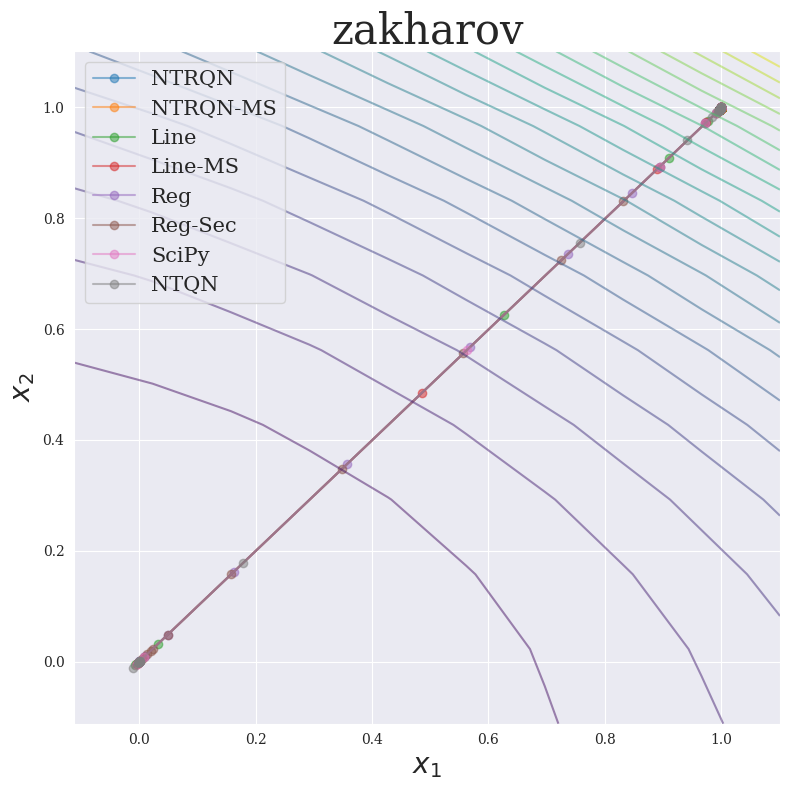

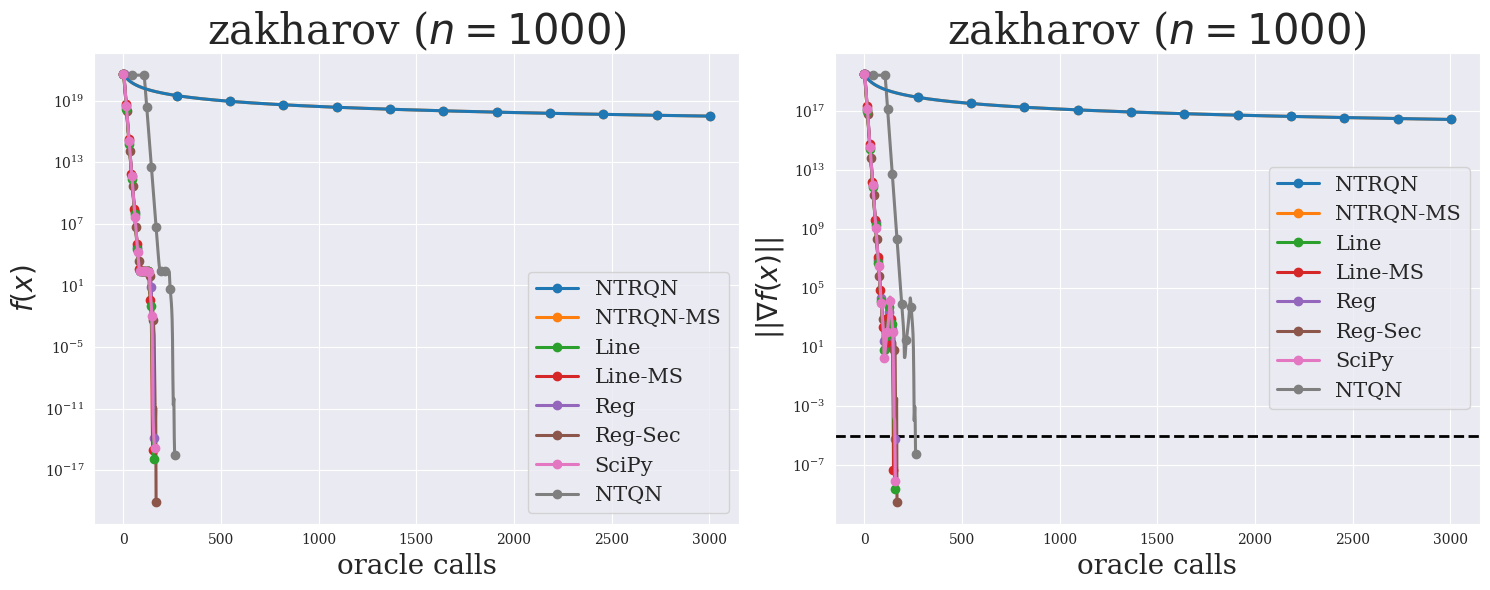

Done.


In [2]:
import numpy as np

# from data.CUTEst.check_CUTEst_problems import problemsToRun
from qnlab.experiment.trial import trial
from qnlab.problem import (
    CUTEstQNProblem,
    DixonPriceProblem,
    IllQuadraticProblem,
    NonConvexProblem,
    PolynomialProblem,
    PowellProblem,
    RosenbrockProblem,
    SpiralProblem,
    StairProblem,
    ZakharovProblem,
)
from qnlab.problem.cutest_noised import CUTEstNoisedProblem
from qnlab.util.method import get_methods

methods, *_ = get_methods(m=10, MI=1500)

if True:
    # prob = NonConvexProblem(n=1)
    # trial(prob, "NonConvex", methods)

    # prob = PolynomialProblem(n=1, c_0=0.0, c_1=0.0, c_2=-1.0, c_3=0.0, c_4=0.0)
    # trial(prob, "-x^2", methods)

    # prob = PolynomialProblem(n=1, c_0=1.0, c_1=2.0, c_2=1.0, c_3=0.1, c_4=0.1)
    # trial(prob, "Polynomial", methods)

    # prob = IllQuadraticProblem(n=100)
    # trial(prob, "ill-quadratic", methods)

    # prob = DixonPriceProblem()
    # trial(prob, "DixonPrice", methods)

    # prob = PowellProblem()
    # trial(prob, "Powell", methods)

    # prob = RosenbrockProblem(n=2)
    # trial(prob, "Rosenbrock", methods)

    # prob = SpiralProblem(n=2)
    # callbacks = trial(prob, "Spiral", methods)

    # prob = StairProblem(n=1)
    # trial(prob, "Stair", methods)

    prob = ZakharovProblem(n=1000)
    trial(prob, "zakharov", methods)

if False:
    problems = [
        "AKIVA",
        "ARGLINA",
        "ARGLINB",
        "ARGLINC",
        "ARWHEAD",
        "BA-L1LS",
        "BDQRTIC",
        "BENNETT5LS",
        "BIGGS6",
        "BOXBODLS",
        "BOXPOWER",
        "BROWNAL",
        "BROYDNBDLS",
        "CRAGGLVY",
        "DIXMAANC",
        "ENGVAL2",
        "ERRINRSM",
        "FMINSRF2",
        "HEART8LS",
        "HUMPS",
        "JENSMP",
        "MEYER3",
        "MGH10LS",
        "MGH17LS",
        "PALMER3C",
        "POWELLSG",
        "ROSZMAN1LS",
        "STRATEC",
        "TRIDIA",
        "VIBRBEAM",
        "VESUVIOLS",
        "YFITU",
    ]

    for name in problems:
        for precision in [16]:
            if name in problemsToRun(precision):
                prob = CUTEstQNProblem(name, precision)
                try:
                    trial(prob, name, methods)
                except Exception as e:  # noqa: BLE001 - continue the experiment batch
                    print(f"Problem {name} failed with exception: {e}")

        prob = CUTEstNoisedProblem(
            name,
            64,
            function_noise=np.float64(1e-3),
            gradient_noise=np.float64(1e-3),
        )
        trial(prob, name, methods)


print("Done.")